In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [19]:
# Load the dataset
data = pd.read_excel('/content/Untitled form (Responses).xlsx', engine='openpyxl')


In [20]:
# Check for missing values
print(data.isnull().sum())

# Fill missing values or drop them
data = data.dropna()  # or use data.fillna(method='ffill') to fill missing values

Timestamp                                                                                  0
What is your age?                                                                          0
What is your gender? (Assign numbers: Male = 1, Female = 2, Other = 3)                     0
  What is your current BMI (Body Mass Index)?                                              0
How many chronic conditions do you currently have? (e.g., diabetes, hypertension, etc.)    3
How many times have you been readmitted to the hospital in the past 12 months?             0
On average, how long is your hospital stay (in days) when admitted for treatment?          0
 On a scale of 1-10, how would you rate your pain level during treatment?                  0
How many medical checkups or visits have you had in the past year?                         0
What percentage of your prescribed medications do you take as directed? (0-100%)           0
What is the estimated cost of your treatment over the past 12 months (

In [5]:
# Check for missing values
print(data.isnull().sum())

Timestamp                                                                                  0
What is your age?                                                                          0
What is your gender? (Assign numbers: Male = 1, Female = 2, Other = 3)                     0
  What is your current BMI (Body Mass Index)?                                              0
How many chronic conditions do you currently have? (e.g., diabetes, hypertension, etc.)    0
How many times have you been readmitted to the hospital in the past 12 months?             0
On average, how long is your hospital stay (in days) when admitted for treatment?          0
 On a scale of 1-10, how would you rate your pain level during treatment?                  0
How many medical checkups or visits have you had in the past year?                         0
What percentage of your prescribed medications do you take as directed? (0-100%)           0
What is the estimated cost of your treatment over the past 12 months (

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                                                                                   Non-Null Count  Dtype         
---  ------                                                                                   --------------  -----         
 0   Timestamp                                                                                48 non-null     datetime64[ns]
 1   What is your age?                                                                        48 non-null     object        
 2   What is your gender? (Assign numbers: Male = 1, Female = 2, Other = 3)                   48 non-null     int64         
 3     What is your current BMI (Body Mass Index)?                                            48 non-null     float64       
 4   How many chronic conditions do you currently have? (e.g., diabetes, hypertension, etc.)  48 non-null     object        
 5   How many times have yo

In [21]:
# Rename the columns
data.rename(columns={
    'What is your age?': 'Age',
    'What is your gender? (Assign numbers: Male = 1, Female = 2, Other = 3)': 'Gender',
    '  What is your current BMI (Body Mass Index)?  ': 'BMI',
    'How many chronic conditions do you currently have? (e.g., diabetes, hypertension, etc.)': 'Chronic_Conditions',
    'How many times have you been readmitted to the hospital in the past 12 months?': 'Readmissions_12m',
    'On average, how long is your hospital stay (in days) when admitted for treatment?  ': 'Avg_Hospital_Stay_Days',
    ' On a scale of 1-10, how would you rate your pain level during treatment?  ': 'Pain_Level_1_10',
    'How many medical checkups or visits have you had in the past year?': 'Medical_Checkups_Year',
    'What percentage of your prescribed medications do you take as directed? (0-100%)': 'Medication_Adherence_Percentage',
    'What is the estimated cost of your treatment over the past 12 months (in USD)?': 'Treatment_Cost_USD'
}, inplace=True)


In [22]:
# Apply Label Encoding to categorical columns
label_encoder = LabelEncoder()
data['Age'] = label_encoder.fit_transform(data['Age'])
data['Chronic_Conditions'] = label_encoder.fit_transform(data['Chronic_Conditions'])

In [23]:
data.columns

Index(['Timestamp', 'Age', 'Gender', 'BMI', 'Chronic_Conditions',
       'Readmissions_12m', 'Avg_Hospital_Stay_Days', 'Pain_Level_1_10',
       'Medical_Checkups_Year', 'Medication_Adherence_Percentage',
       'Treatment_Cost_USD'],
      dtype='object')

In [24]:
# Step 3: Scale the data (only applicable for continuous numeric data)
scaler = StandardScaler()
numeric_columns = ['BMI', 'Readmissions_12m', 'Avg_Hospital_Stay_Days', 'Pain_Level_1_10',
                   'Medical_Checkups_Year', 'Medication_Adherence_Percentage', 'Treatment_Cost_USD']
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])

In [25]:
# Step 4: Drop the Timestamp column
data.drop('Timestamp', axis=1, inplace=True)


In [26]:
# Output the processed data
print(data.head())

   Age  Gender       BMI  Chronic_Conditions  Readmissions_12m  \
0    0       1 -0.408718                   2         -0.102483   
1    6       2 -1.275720                   6          1.537242   
2    6       2  0.337308                   5          1.537242   
3    2       1  1.284961                   5         -1.086318   
4    1       2 -0.852300                  10         -1.742208   

   Avg_Hospital_Stay_Days  Pain_Level_1_10  Medical_Checkups_Year  \
0               -0.625969         0.122169              -0.449325   
1                0.312984         1.099525               1.235643   
2               -0.625969        -0.366508               1.909630   
3               -0.938953        -0.366508              -1.123312   
4                0.000000        -0.366508               0.224662   

   Medication_Adherence_Percentage  Treatment_Cost_USD  
0                        -0.411853           -2.299114  
1                         1.809377           -1.028029  
2                

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Data Overview and Summary Statistics
print("Data Overview:")
print(data.info())
print("\nSummary Statistics:")
print(data.describe())

Data Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              48 non-null     int64  
 1   Gender                           48 non-null     int64  
 2   BMI                              48 non-null     float64
 3   Chronic_Conditions               48 non-null     int64  
 4   Readmissions_12m                 48 non-null     float64
 5   Avg_Hospital_Stay_Days           48 non-null     float64
 6   Pain_Level_1_10                  48 non-null     float64
 7   Medical_Checkups_Year            48 non-null     float64
 8   Medication_Adherence_Percentage  48 non-null     float64
 9   Treatment_Cost_USD               48 non-null     float64
dtypes: float64(7), int64(3)
memory usage: 4.1 KB
None

Summary Statistics:
             Age     Gender           BMI  Chronic_Conditions  \
co

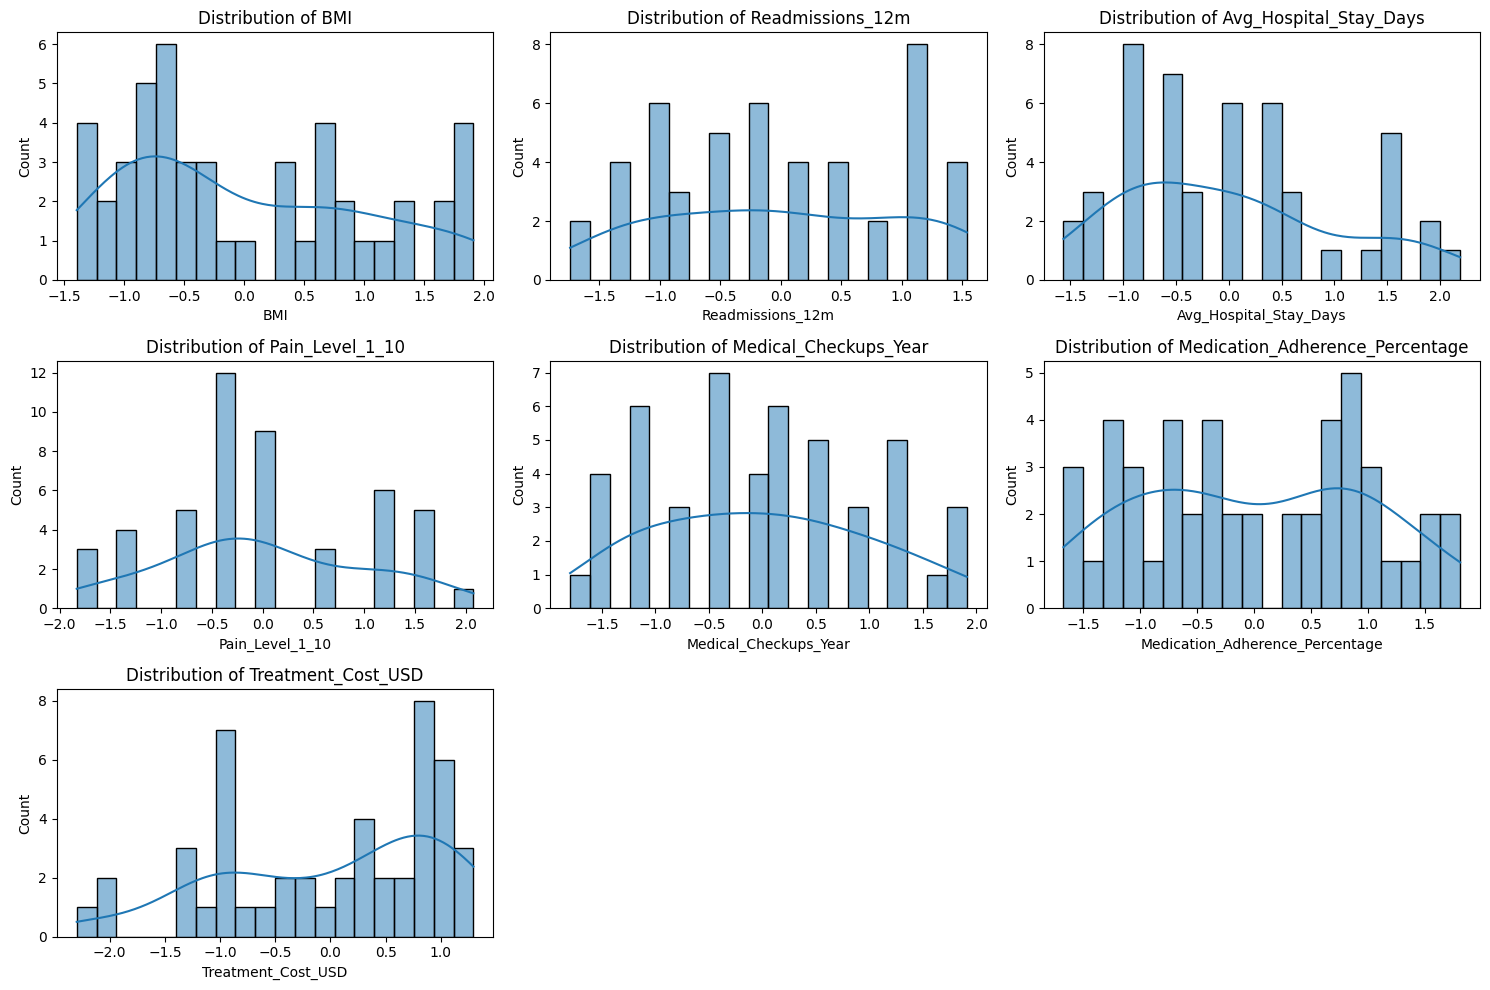

In [28]:
# Step 2: Visualize Distributions of Numerical Features
numeric_columns = ['BMI', 'Readmissions_12m', 'Avg_Hospital_Stay_Days',
                   'Pain_Level_1_10', 'Medical_Checkups_Year',
                   'Medication_Adherence_Percentage', 'Treatment_Cost_USD']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

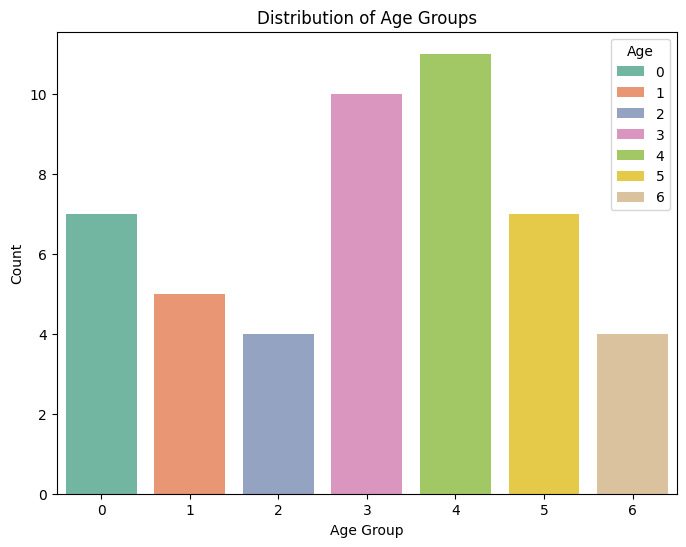

In [33]:
# Step 3: Visualize Categorical Features
# Age Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Age', data=data, palette='Set2', hue = 'Age')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

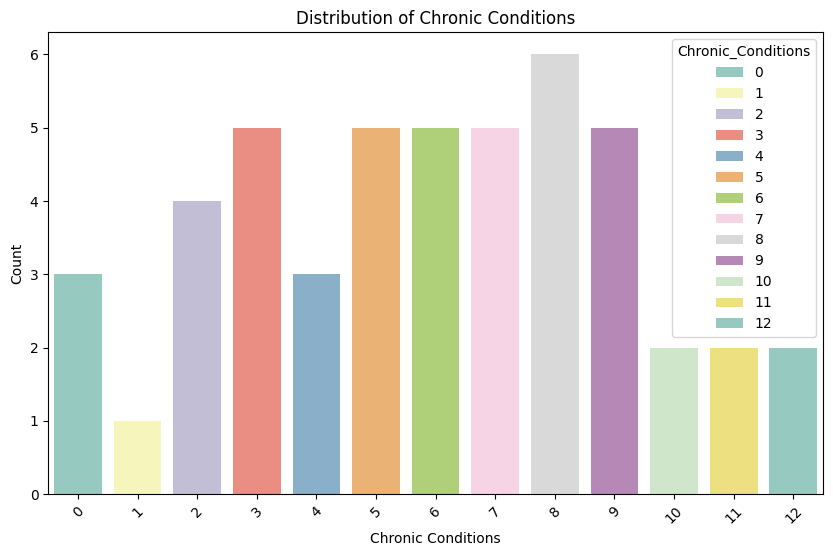

In [32]:
# Chronic Conditions Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Chronic_Conditions', data=data, palette='Set3', hue= 'Chronic_Conditions')
plt.title('Distribution of Chronic Conditions')
plt.xticks(rotation=45)
plt.xlabel('Chronic Conditions')
plt.ylabel('Count')
plt.show()

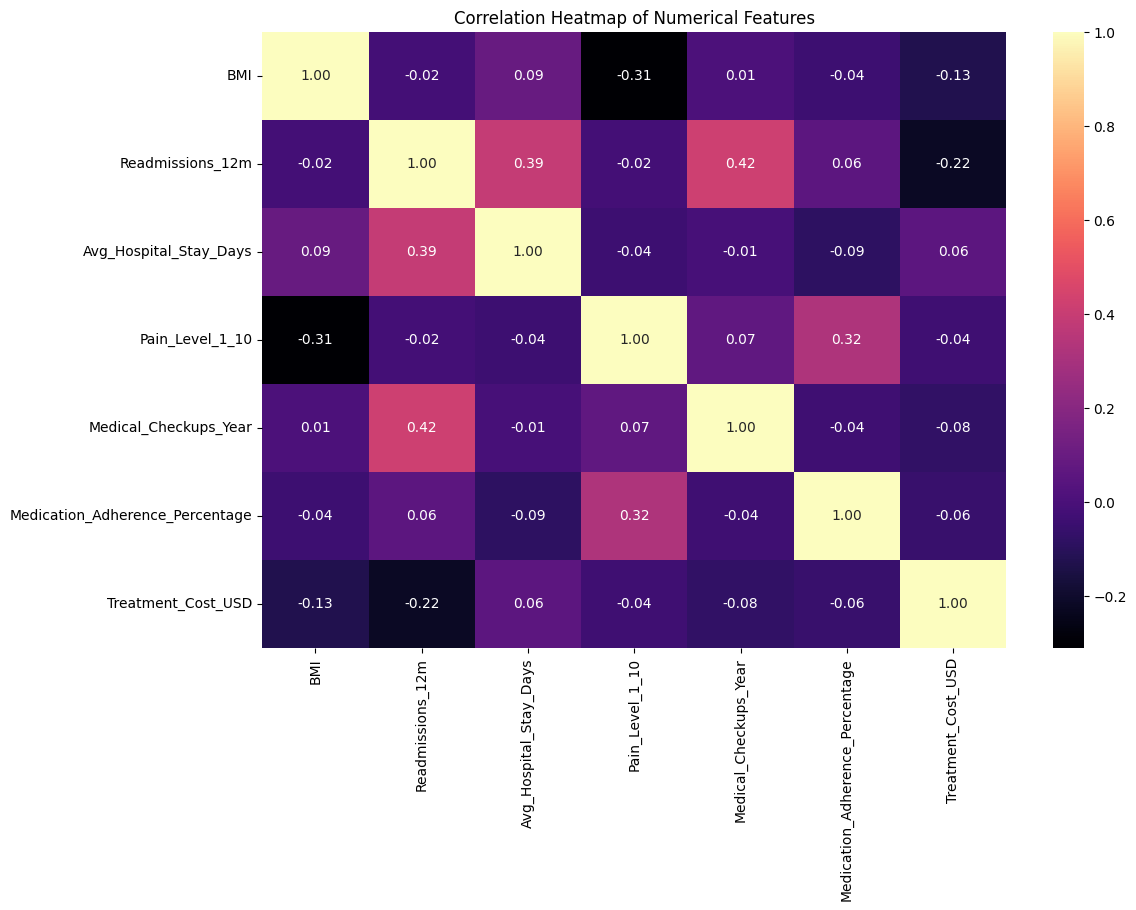

In [34]:
# Step 4: Correlation Heatmap for Numerical Features
plt.figure(figsize=(12, 8))
correlation_matrix = data[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

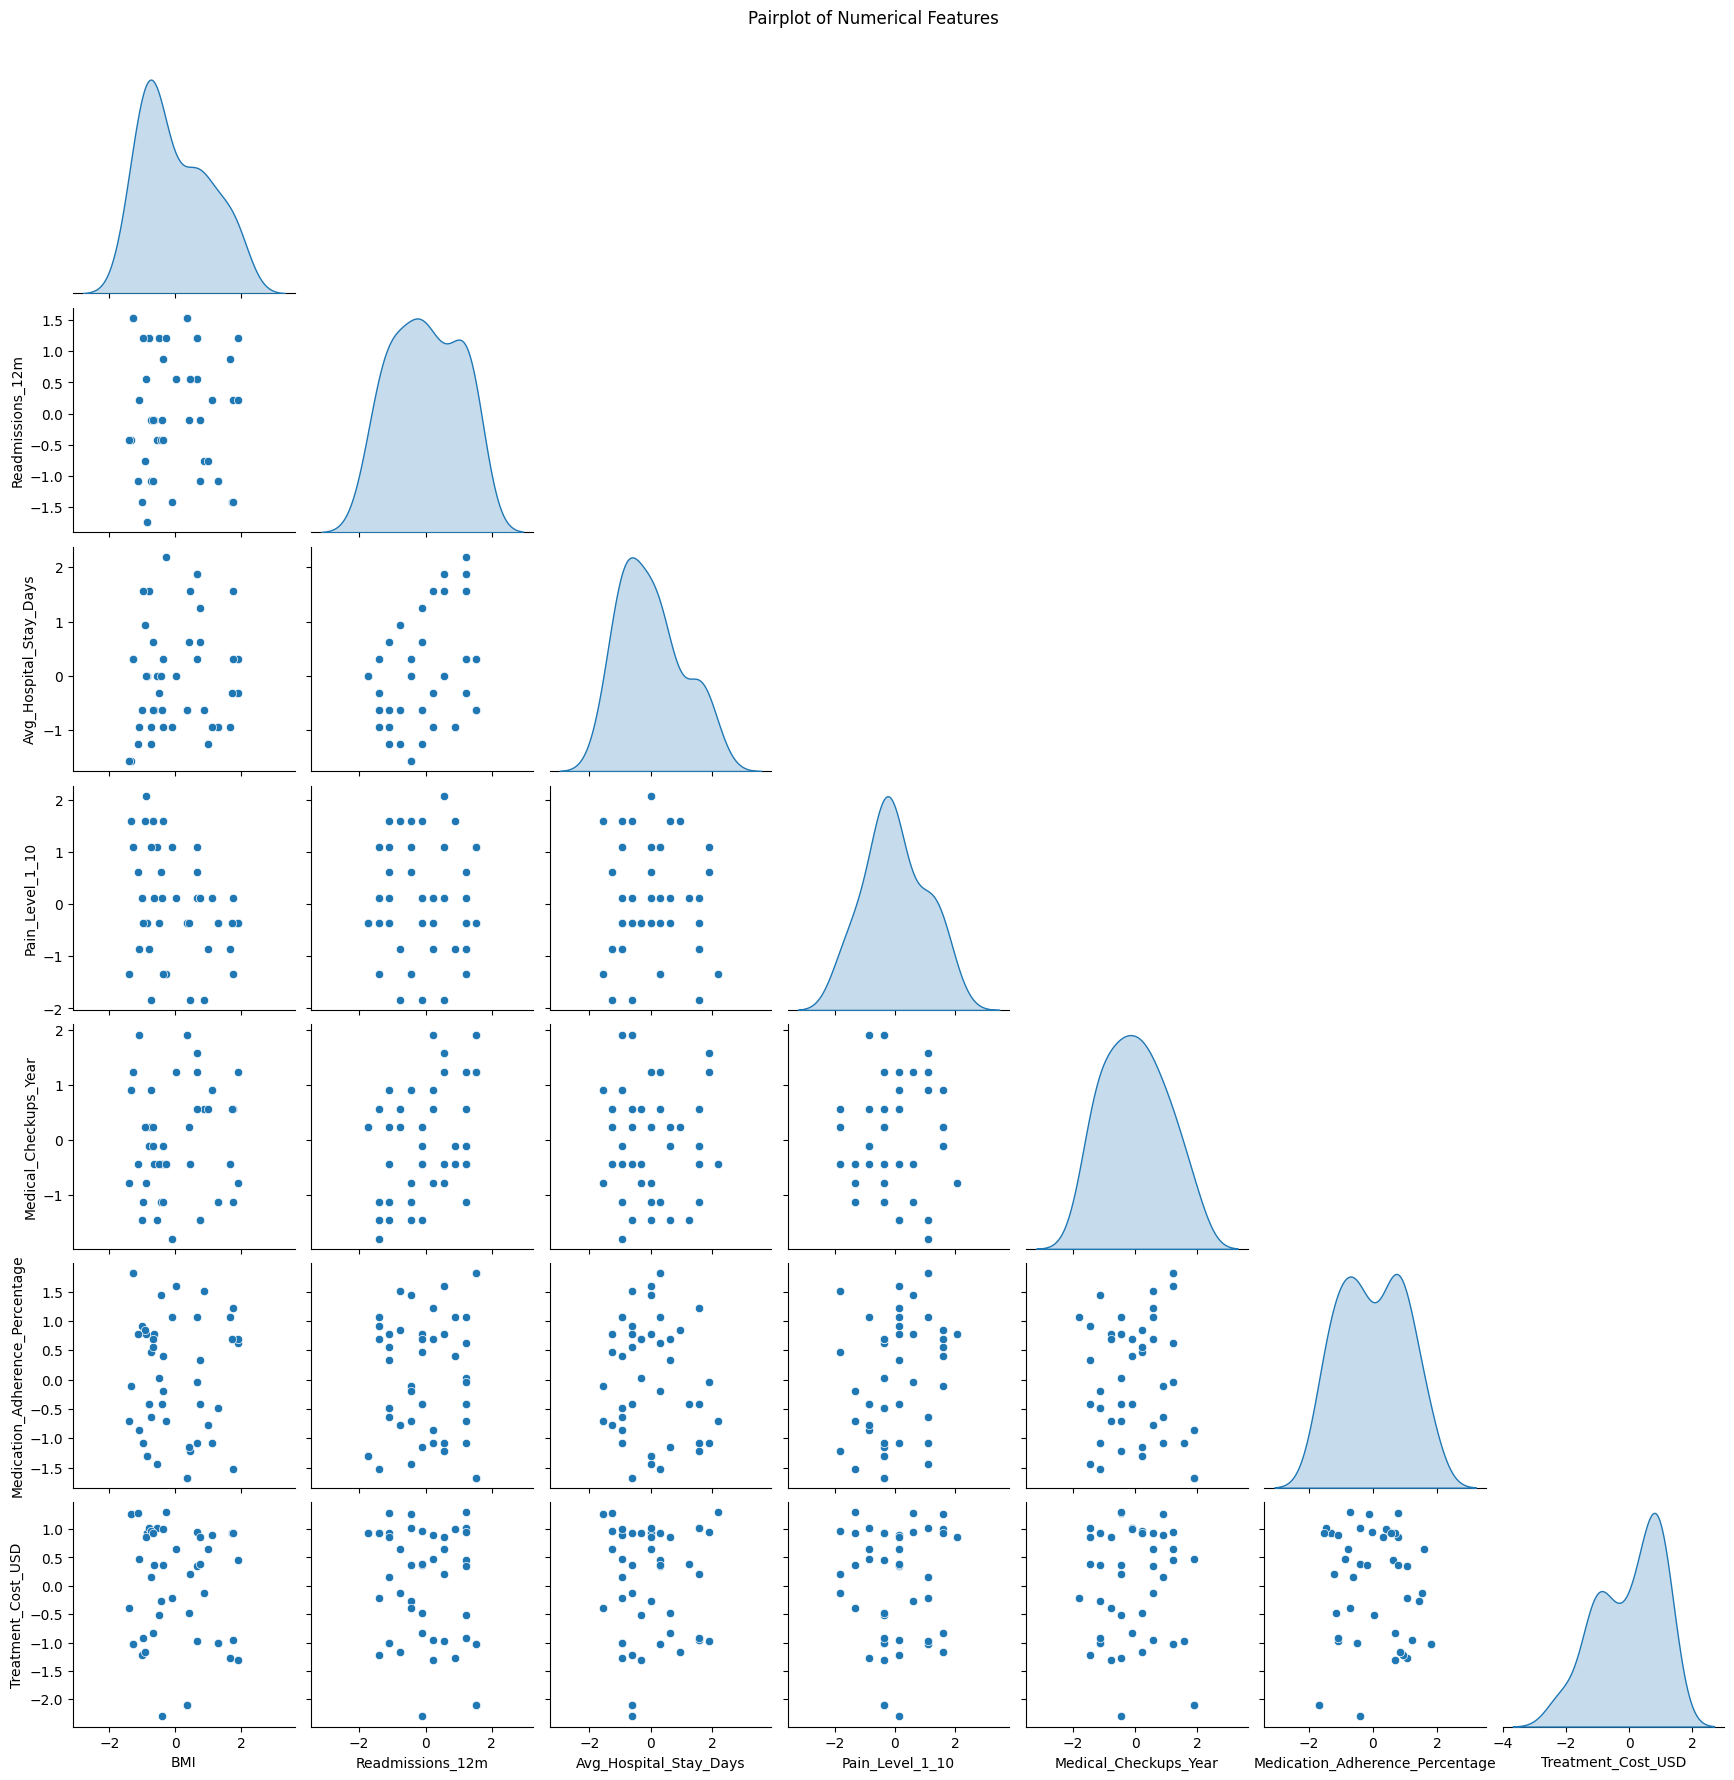

In [36]:
# Step 5: Pairplot for Multivariate Analysis
sns.pairplot(data[numeric_columns], diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

<ipython-input-37-43971b624a49>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age', y='Treatment_Cost_USD', data=data, palette='Set1')


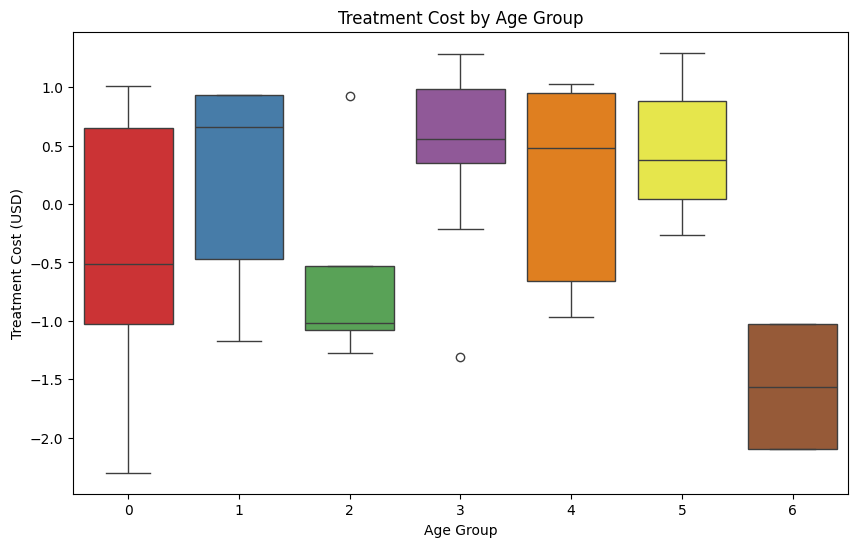

In [37]:
# Step 6: Customized Visualizations for Key Features
# Boxplot for Treatment Cost based on Age Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Age', y='Treatment_Cost_USD', data=data, palette='Set1')
plt.title('Treatment Cost by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Treatment Cost (USD)')
plt.show()

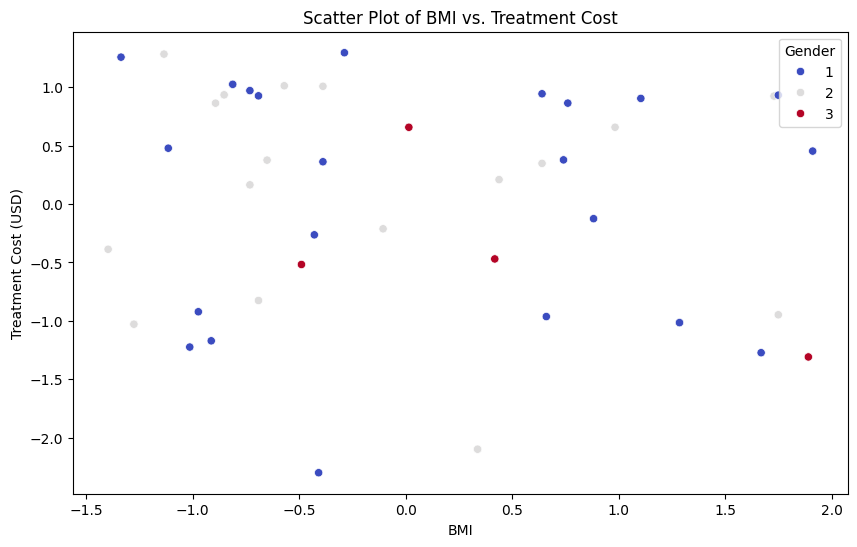

In [38]:
# Scatter Plot for BMI vs. Treatment Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BMI', y='Treatment_Cost_USD', hue='Gender', data=data, palette='coolwarm')
plt.title('Scatter Plot of BMI vs. Treatment Cost')
plt.xlabel('BMI')
plt.ylabel('Treatment Cost (USD)')
plt.show()

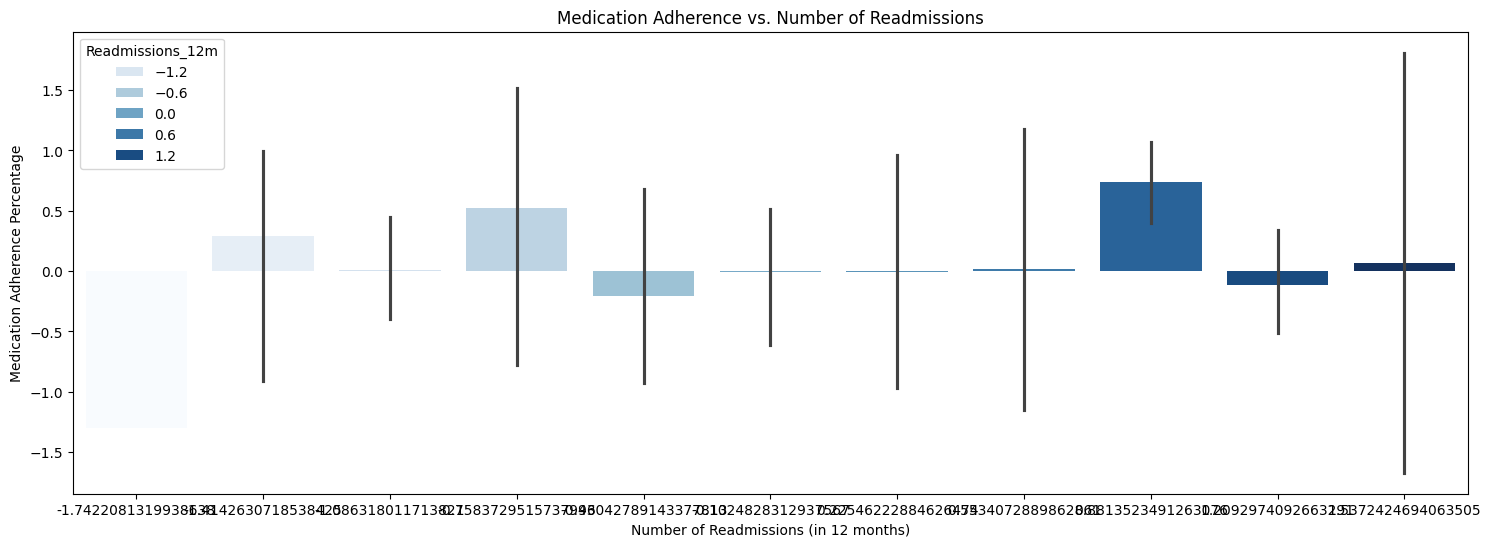

In [41]:
# Bar Plot for Readmissions vs. Medication Adherence
plt.figure(figsize=(18, 6))
sns.barplot(x='Readmissions_12m', y='Medication_Adherence_Percentage', data=data, palette='Blues', hue = 'Readmissions_12m')
plt.title('Medication Adherence vs. Number of Readmissions')
plt.xlabel('Number of Readmissions (in 12 months)')
plt.ylabel('Medication Adherence Percentage')
plt.show()

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Step 1: Select Target Variable and Features
target = 'Treatment_Cost_USD'
features = ['Age', 'Gender', 'BMI', 'Readmissions_12m', 'Avg_Hospital_Stay_Days',
            'Pain_Level_1_10', 'Medical_Checkups_Year', 'Medication_Adherence_Percentage']


In [43]:
X = data[features]
y = data[target]

In [44]:
# Step 2: Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [47]:
# Step 3: Train Multiple Regression Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}


In [48]:
model_results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Step 4: Evaluate the Models
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    model_results[model_name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

    print(f"Model: {model_name}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2): {r2:.2f}\n")


Model: Linear Regression
Mean Absolute Error (MAE): 0.87
Mean Squared Error (MSE): 1.42
Root Mean Squared Error (RMSE): 1.19
R-squared (R2): -1.36

Model: Ridge Regression
Mean Absolute Error (MAE): 0.84
Mean Squared Error (MSE): 1.36
Root Mean Squared Error (RMSE): 1.16
R-squared (R2): -1.25

Model: Lasso Regression
Mean Absolute Error (MAE): 0.73
Mean Squared Error (MSE): 0.84
Root Mean Squared Error (RMSE): 0.92
R-squared (R2): -0.39

Model: Decision Tree
Mean Absolute Error (MAE): 1.19
Mean Squared Error (MSE): 2.28
Root Mean Squared Error (RMSE): 1.51
R-squared (R2): -2.78

Model: Random Forest
Mean Absolute Error (MAE): 0.61
Mean Squared Error (MSE): 0.60
Root Mean Squared Error (RMSE): 0.78
R-squared (R2): 0.00



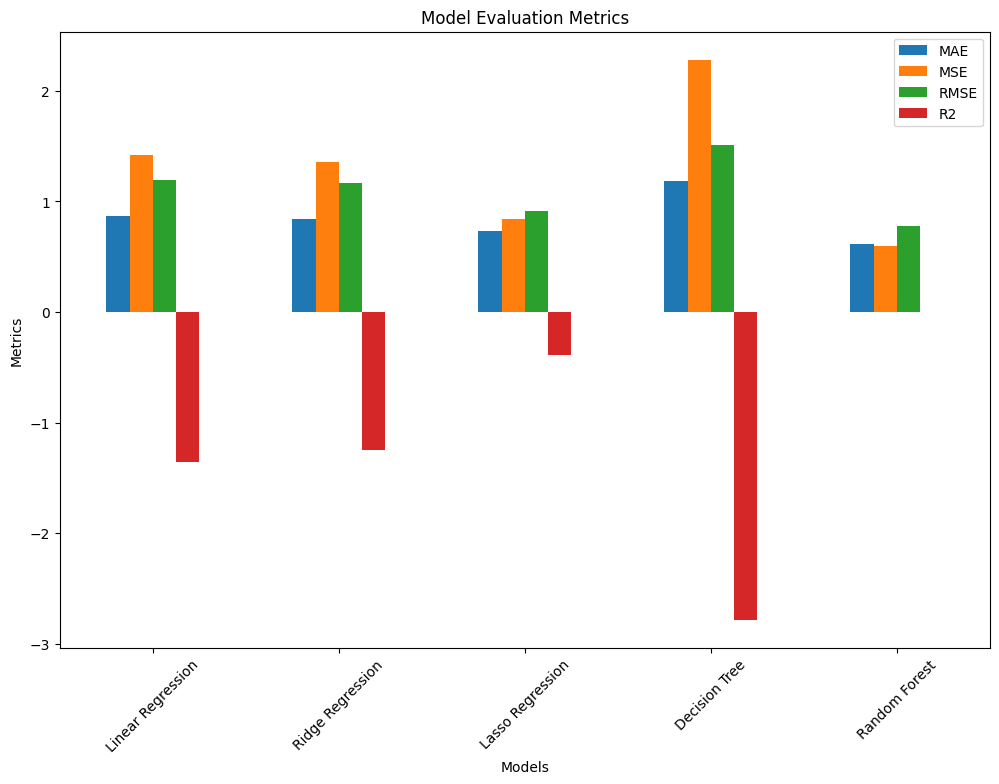

In [49]:
# Step 5: Plot Evaluation Metrics
results_df = pd.DataFrame(model_results).T
results_df.plot(kind='bar', figsize=(12, 8))
plt.title('Model Evaluation Metrics')
plt.xlabel('Models')
plt.ylabel('Metrics')
plt.xticks(rotation=45)
plt.show()

In [50]:
# Step 6: Plot Feature Importance for Tree-Based Models (Random Forest)
# Feature Importance for Random Forest
rf_model = models['Random Forest']
feature_importances = rf_model.feature_importances_
feature_names = X.columns

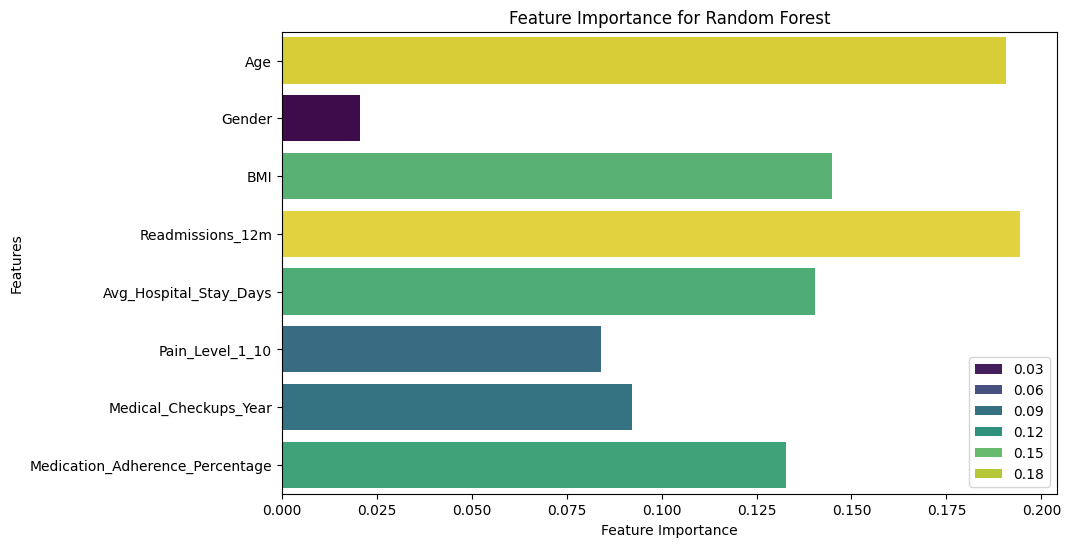

In [54]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names, palette='viridis', hue = feature_importances)
plt.title('Feature Importance for Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()

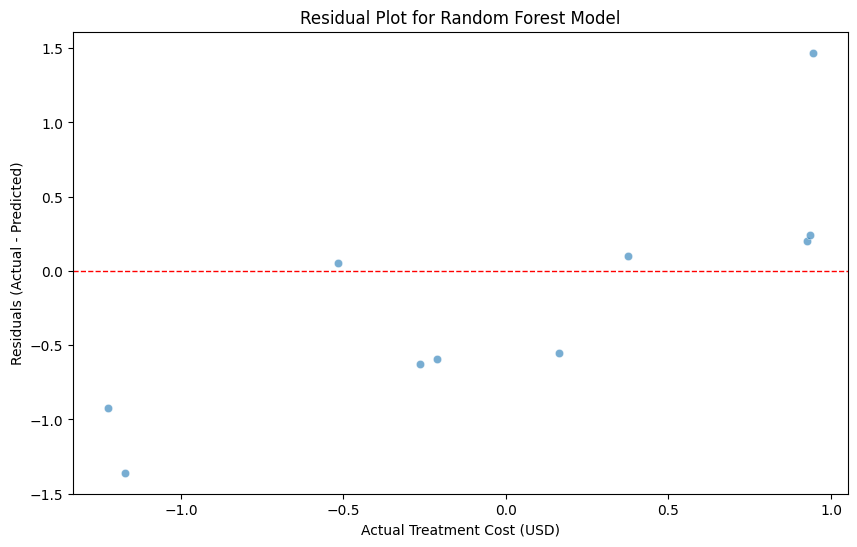

In [52]:
# Predict the values for the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Residual Plot
residuals = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot for Random Forest Model')
plt.xlabel('Actual Treatment Cost (USD)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()


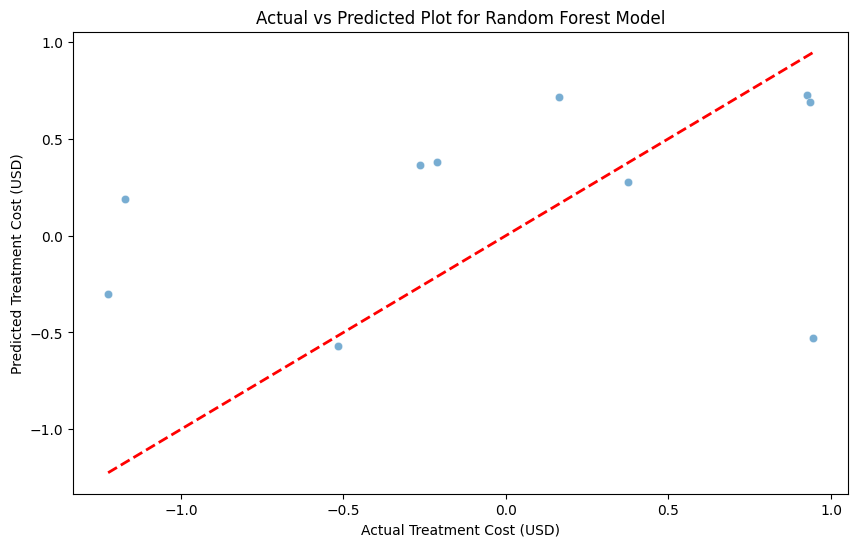

In [53]:
# Actual vs. Predicted Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # Line for perfect prediction
plt.title('Actual vs Predicted Plot for Random Forest Model')
plt.xlabel('Actual Treatment Cost (USD)')
plt.ylabel('Predicted Treatment Cost (USD)')
plt.show()

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

In [57]:
# Create a DataFrame for Feature Importances
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

In [58]:
# Select Top Features Based on Importance
top_features = importance_df['Feature'].head(5).tolist()

# Step 2: Prepare the Data Using Top Features
X_top = data[top_features]
y = data['Treatment_Cost_USD']

In [59]:
# Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42)


In [61]:
# Set Up Hyperparameter Tuning with GridSearchCV
# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'max_features': ['auto', 'sqrt', 'log2']  # Number of features to consider when looking for the best split
}

# Initialize the RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

In [62]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error', verbose=2)

In [63]:
# Extract Best Parameters and Best Model
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

print("Best Hyperparameters for Random Forest:", best_params)

Best Hyperparameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [64]:
# Evaluate the Tuned Model
y_pred = best_rf_model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 0.63
Mean Squared Error (MSE): 0.65
Root Mean Squared Error (RMSE): 0.80
R-squared (R2): -0.07


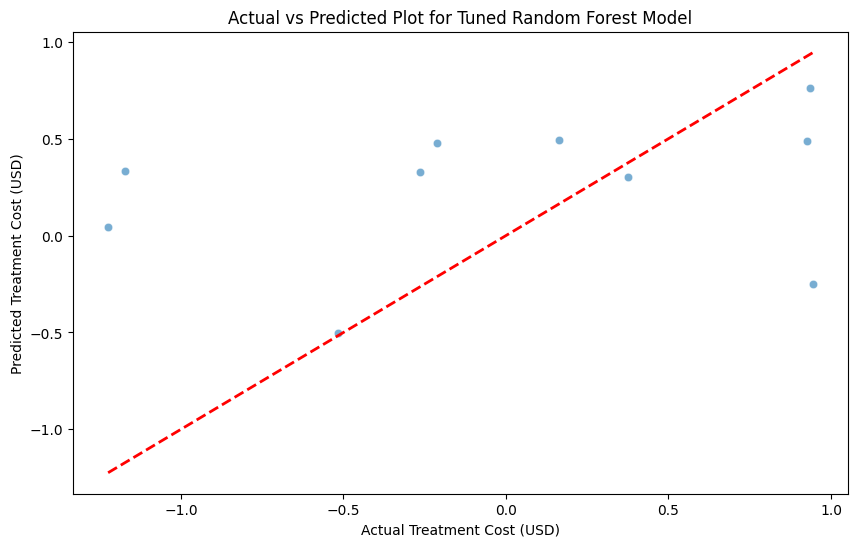

In [65]:
# Plot Actual vs Predicted for Tuned Model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted Plot for Tuned Random Forest Model')
plt.xlabel('Actual Treatment Cost (USD)')
plt.ylabel('Predicted Treatment Cost (USD)')
plt.show()

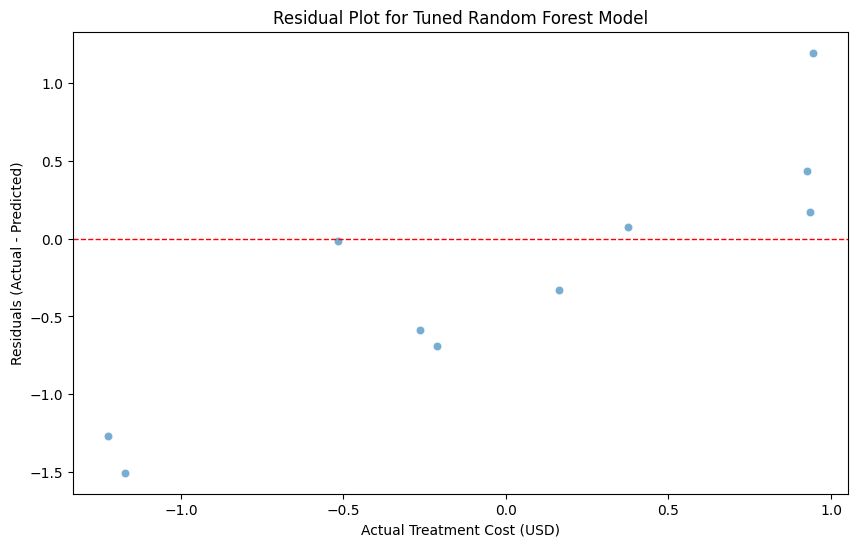

In [66]:
# Plot Residuals for Tuned Model
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot for Tuned Random Forest Model')
plt.xlabel('Actual Treatment Cost (USD)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()